<center><h1>MINERIA DE DATOS</h1>
<strong>Taller Agrupación</strong><br />
PROFESORA ELIZABETH LEON GUZMAN <br />
<strong>TEMA</strong> Algoritmos de Agrupación - algoritmos</center>

-------

##DBSCAN


<Axes: xlabel='x', ylabel='y'>

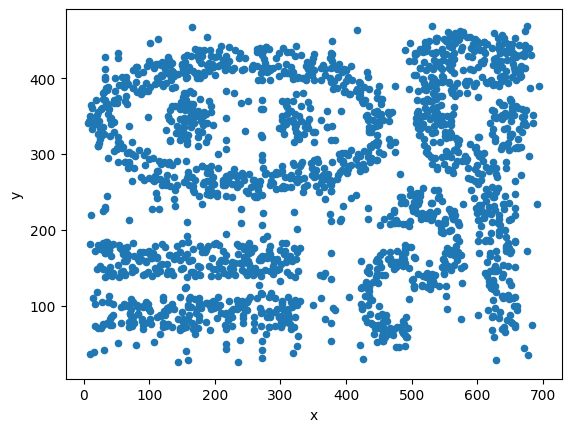

In [ ]:
# Lectura del archivo chameleon
import pandas as pd

data = pd.read_csv('chameleon.data', delimiter=' ', names=['x','y'])
data.plot.scatter(x='x',y='y')

<Axes: xlabel='x', ylabel='y'>

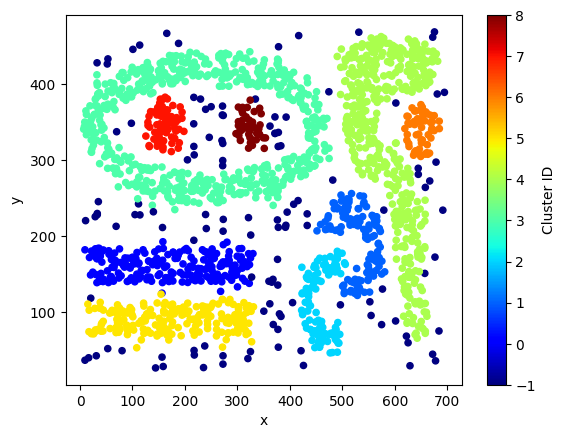

In [ ]:
#Aplicacion del algoritmo DBSCAN
from sklearn.cluster import DBSCAN
import numpy as np

db = DBSCAN(eps=15.5, min_samples=5).fit(data)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = pd.DataFrame(db.labels_,columns=['Cluster ID'])
result = pd.concat((data,labels), axis=1)
result.plot.scatter(x='x',y='y',c='Cluster ID', colormap='jet')

**Ejercicio 1**

Variar epsilon y min_samples.Analice los resultados.

**Ejercicio 2**

Aplicar el algoritmo DBScan a otro conjunto de datos. Analice los resultados variando epsilon y min_samples

##Gaussian Mixture Model (GMM)

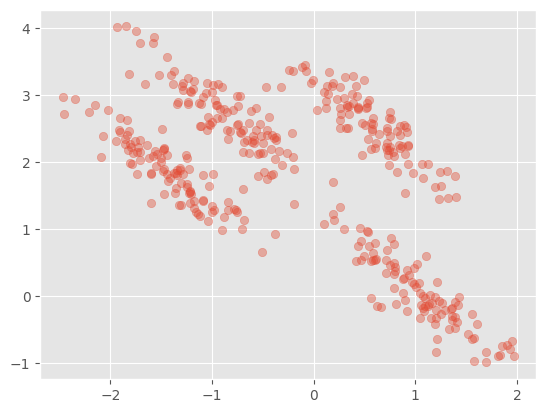

In [ ]:
# Importamos librerías
import numpy as np
np.random.seed(0)
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")

# Creamos un dataset sintético de cuatro clusters no circulares
X, _ = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
rng = np.random.RandomState(13)
X=np.dot(X, rng.randn(2, 2))

plt.scatter(X[:,0],X[:,1],alpha=0.4)

In [ ]:

from sklearn.mixture import GaussianMixture

model=GaussianMixture(n_components=4, covariance_type='full', random_state=40)
model.fit(X)

GaussianMixture(n_components=4, random_state=40)

Text(0.5, 1.0, 'GMM')

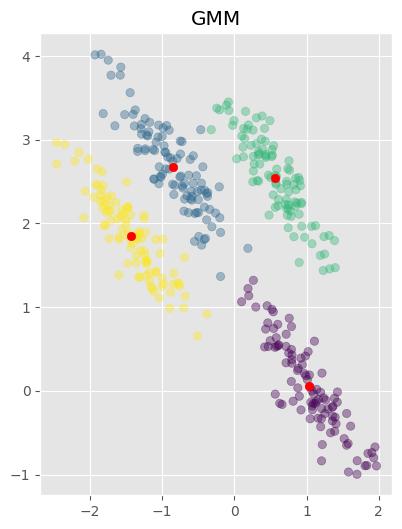

In [ ]:
# Se dibujan los clusters obtenidos
plt.figure(figsize=(10,6))
pred2=model.predict(X)
plt.subplot(122)
plt.scatter(X[:,0],X[:,1],c=pred2,alpha=0.4)
plt.scatter(model.means_[:,0],model.means_[:,1],c="r")
plt.title("GMM")

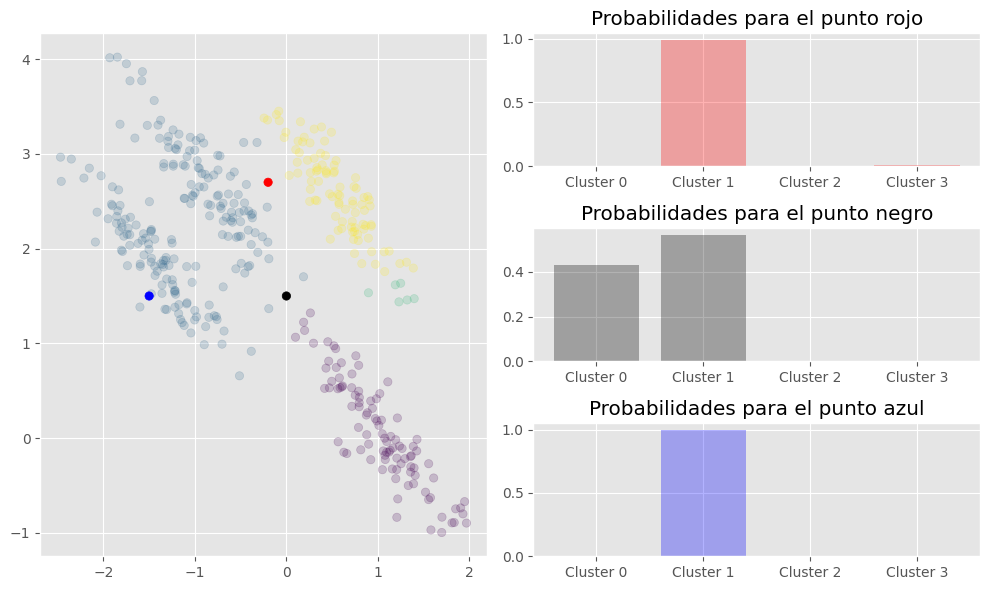

In [ ]:
# En este ejmplo se visualizará la representación probabilística de tres puntos seleccionados:
# punto rojo, punto negro y punto azul (en la gráfica1). Se escogen estos puntos que se
# encuentran en la frontera con el fin de que pertenezcan a más de un cluster.

#Cambiar aqui la coordenada de los puntos y revisar el que se quiere evaluar

plt.figure(figsize=(10,6))
point=np.array([[-0.2,2.7],
                [0,1.5],
                [-1.5,1.5]])
probs=model.predict_proba(point)
plt.subplot(121)
plt.scatter(X[:,0],X[:,1],c=pred2,alpha=0.2)
plt.scatter(point[:,0],point[:,1],c=["r","k","b"])
plt.subplot(322)
plt.bar(["Cluster {}".format(i) for i in range(4)],probs[0].flatten(), color="r", alpha=0.3)
plt.title("Probabilidades para el punto rojo")
plt.subplot(324)
plt.bar(["Cluster {}".format(i) for i in range(4)],probs[1].flatten(), color="k", alpha=0.3)
plt.title("Probabilidades para el punto negro")
plt.subplot(326)
plt.bar(["Cluster {}".format(i) for i in range(4)],probs[2].flatten(), color="b", alpha=0.3)
plt.title("Probabilidades para el punto azul")
plt.tight_layout()

**Ejercicio 2**: ¿Cuáles serían las probabilidades para el punto (-1.5,1.5)?

**Ejercicio 3**: Ejecutar el algoritmo Kmean con este conjunto de datos. Comparar visualmente los resultados de los dos modelos.

**Ejercicio 4**: Aplicar DBScan al conjunto de datos


**Ejercicio 5 - Conclusiones**: Explicar y analizar los resultados de aplicar GMM,k-means y DBSCAN.



---------
**Referencias**

[1] TAN y otros. Introduction to Data Mining  (segunda edición)

[2] George Karypis, Eui-Hong Han, and Vipin Kumar. CHAMELEON: A Hierarchical Clustering Algorithm Using Dynamic Modeling. IEEE Computer 32(8): 68-75, 1999.
